In [1]:
# Import modules
import pandas as pd
import numpy as np
import xarray as xr
import scipy.stats as sp
import matplotlib.pyplot as plt
import matplotlib.colors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import ipywidgets as widgets
import re
import os

from matplotlib.ticker import AutoMinorLocator
from matplotlib.colors import BoundaryNorm

from IPython.display import Image
from IPython.display import display

import sys
sys.path.insert(1, '../Modules/')
from EPE_detection import *

# Outline:

In this notebook, we define the target variable we aim to predict using a data-driven approach. This is obtained through the following steps:

- Step 1: Select the parameters that define our target variable
- Step 2: Select the location we want to consider
- Step 3: Open the daily total precipitation dataset
- Step 4: Compute the target variable from the total precipitation dataset
- Step 5: Increase the sample size using a data augmentation technique
- Step 6: Save the target variable

Cells marked with the “->” symbol require user action.

# Step-1 - Set up parameters

What are the extreme/intense precipitation events? 

There are multiple possible definition that are typically related to the amount of water falling to the Earth’s surface over a given **accumulation** period.
The choice of the definition (e.g., frequency, intensity) depends on application needs and highlights different physical processes (e.g., large-scale, convective).

In this case, we will consider a frequency-oriented definition, namely the number of events in a specific season exceeding a **threshold** calculated as a selected percentile Q of the climatological distribution (NQp).



-> Define the percentile **threshold** for identifying the events of interest. Depending on the magnitude of the percentile considered, we distinguish between intense and extreme precipitation events.

In [2]:
threshold_widget=widgets.Dropdown(
    options=[85, 90, 95, 99],
    value=90,
    description='Threshold (percentile):',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='200px')
)

threshold_widget

Dropdown(description='Threshold (percentile):', index=1, layout=Layout(width='200px'), options=(85, 90, 95, 99…

-> Define the **accumulation** period (days). Longer-duration events, which are typically associated with large-scale dynamical processes rather than convective phenomena, are therefore expected to exhibit greater predictability at seasonal time scales.

In [3]:
accumulation_widget = widgets.IntSlider(
    value=3,                    # Default value
    min=1,                      # Minimum duration
    max=5,                     # Maximum duration  
    step=2,                     # Step size
    description='Accumulation days:',
    style={'description_width': 'initial'},
    layout=widgets.Layout(width='400px')
)

accumulation_widget

IntSlider(value=3, description='Accumulation days:', layout=Layout(width='400px'), max=5, min=1, step=2, style…

In [4]:
# check the values
quantile=threshold_widget.value/100
accumulation_time=accumulation_widget.value

print ("Threshold: ", quantile)
print ("Accumulation time: ", accumulation_time)

Threshold:  0.9
Accumulation time:  3


Here, we define the **climatology** years, the threshold for dry days (which are not considered), and the **season** of interest (in this case AMJ, i.e. April-May-June).

In [5]:
# years for quantiles definition
first_clima_year = 1993
last_clima_year = 2016

# define the threshold for dry days
dry_threshold = 0.2*1e-3 # m/day

# define dictionary for seasons
season = 'AMJ'
seasonal_dict = {
    'AMJ' : {'pred_date':'-03-31',  'months': [4, 5, 6]}
}
months = seasonal_dict[season]['months']

# Step-2 - select location

-> Select the target location within Europe.

In [6]:
region="Cluj-Napoca"
lon='''23°33'00"E'''
lat='''46°46'00"N'''

# region = 'Southern-France'
# lon='''5°30'0"E'''
# lat='''45°30'0"N'''

# region = 'Denmark'
# lon='''9°15'0"E'''
# lat='''56°0'0"N'''

# region = 'Gerona'
# lon='''2°49'0"E'''
# lat='''41°59'0"N'''

# region = 'Bodo'
# lon='''14°22'30.36"E'''
# lat='''67°16'57.72"N'''

# region = 'Nottingham'
# lon='''1°9'4"W'''
# lat='''52°57'22"N'''

# region="Ancona"
# lon='''13°31'00"E'''
# lat='''43°37'00"N'''

# Converts coords to integer value
deg, minutes, seconds, direction =  re.split('[°\'"]', lat)
latP= (float(deg) + float(minutes)/60 + float(seconds)/(60*60)) * (-1 if direction in ['W', 'S'] else 1)
deg, minutes, seconds, direction =  re.split('[°\'"]',lon)
lonP= (float(deg) + float(minutes)/60 + float(seconds)/(60*60)) * (-1 if direction in ['W', 'S'] else 1)

# Step-3 - Data

This dataset is from Copernicus Climate Change Service ERA5: a reanalysis dataset with 0.25° spatial resolution, available from 1940 to the present, considered here at daily temporal resolution.

These data were downloaded from the Copernicus Climate Data Store:

https://cds.climate.copernicus.eu/datasets/derived-era5-single-levels-daily-statistics?tab=overview

Inspect the dataset to better understand its structure (spatial and temporal domains) and characteristics (variables and units).

In [7]:
# open the daily time series of ERA5 TP over the European domain
era5_TP = xr.open_dataarray('../DATA/ERA5_TP_MAMJJ.nc')

In [8]:
era5_TP

<xarray.DataArray 'tp' (time: 13005, latitude: 169, longitude: 249)> Size: 2GB
[547263405 values with dtype=float32]
Coordinates:
    number     int64 8B ...
  * latitude   (latitude) float64 1kB 71.0 70.75 70.5 70.25 ... 29.5 29.25 29.0
  * longitude  (longitude) float64 2kB -17.0 -16.75 -16.5 ... 44.5 44.75 45.0
  * time       (time) datetime64[ns] 104kB 1940-03-01 1940-03-02 ... 2024-07-31
Attributes: (12/32)
    GRIB_paramId:                             228
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      42081
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            accum
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               m
    long_name:                                Total precipitation
    units:                                    m
    standard_name:                            unknown
    GRIB_surface:                             0.0

Select the grid point and the season of interest.

In [9]:
# select the grid point of interest
era5_TP_loc = era5_TP.sel(latitude=latP, longitude=lonP, method='nearest')

# select only the season of interest
era5_TP_loc_seas = era5_TP_loc.where(era5_TP_loc['time'].dt.month.isin(months), drop=True)

Plot the map of a random day to get a view of how data looks like

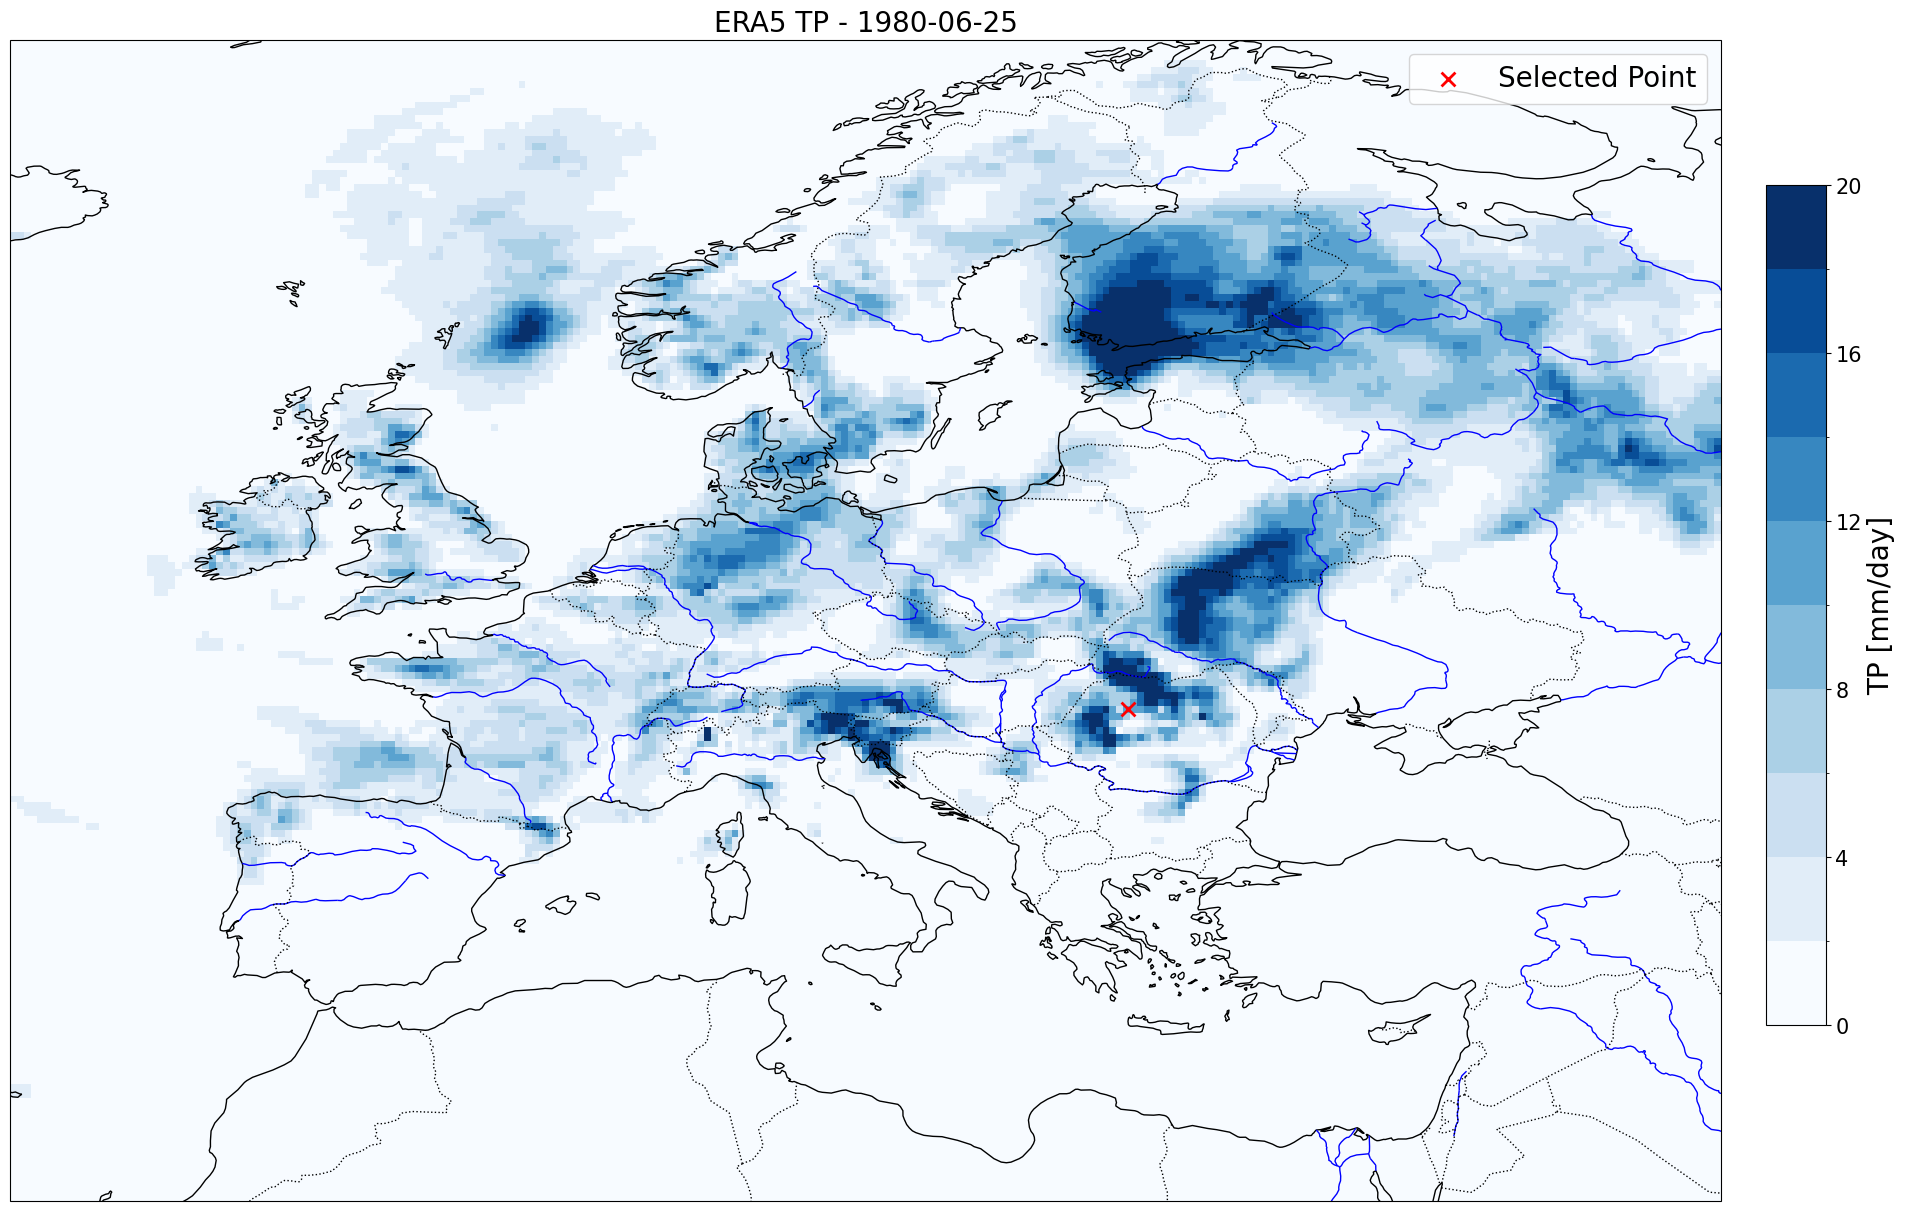

In [10]:
# plot of a random day TP

fig, ax = plt.subplots(figsize=(20, 12), subplot_kw={"projection": ccrs.PlateCarree()}, constrained_layout=True)

# select a random day to look the data
rand_day = np.random.randint(0, len(era5_TP.time)-1)
era5_TP_rand_day = era5_TP.isel(time=rand_day)*1e3 # convert from m to mm

# set max value of the colormap
vmax = 20

# define the colormap
n_bins = 10 # adjust as needed
bounds = np.linspace(0, vmax, n_bins + 1)
cmap = plt.get_cmap("Blues", n_bins) 
norm = BoundaryNorm(bounds, cmap.N)

# plot the dataset
img = (era5_TP_rand_day).plot(ax=ax, transform=ccrs.PlateCarree(), add_colorbar=False, cmap = cmap, norm=norm)

# add coastlines, rivers, borders
ax.coastlines()
ax.add_feature(cfeature.RIVERS, edgecolor="blue")
ax.add_feature(cfeature.BORDERS, linestyle=":", edgecolor="black")

# define the title
ax.set_title('ERA5 TP - {}'.format(era5_TP_rand_day.time.dt.strftime('%Y-%m-%d').values), fontsize=20)

# define the colormap details
cbar_ax = fig.add_axes([0.95, 0.15, 0.03, 0.7])  # [left, bottom, width, height]
cbar = fig.colorbar(img, cax=cbar_ax, label="TP [mm/day]", ticks=None)
cbar.set_label("TP [mm/day]", fontsize=20)
cbar.ax.tick_params(labelsize=15) 


# report the selected grif point
ax.scatter(lonP, latP, 
            color='r',        # choose coloure
            s=100,              # size of the marker
            marker='x',         # marker shape
            linewidth=2,        # thickness 
            transform=ccrs.PlateCarree(),
            label='Selected Point')

ax.legend(fontsize=20)
plt.show()

Accumulate the precipitation over the period selected above and consider only periods in which all the daily values are greater than 0.2 mm/day.

In [11]:
# call the function to calculate the accumulated time series and skip dry days
era5_TP_loc_seas_acc = timeseries_processing(era5_TP_loc_seas, dry_threshold, accumulation_time, months)

Calculate the threshold as the selected percentile across all events in the selected season and the climatology period (1993–2016).

In [12]:
# define a dataset just for climatology years
era5_TP_loc_seas_acc_clima = era5_TP_loc_seas_acc.sel(time=(era5_TP_loc_seas_acc['time'].dt.year >= first_clima_year) & (era5_TP_loc_seas_acc['time'].dt.year <= last_clima_year))

# calculate the selected quantile from the climatology years
q_era5_TP_loc_seas_acc = era5_TP_loc_seas_acc_clima.quantile(quantile, dim=('time'), skipna=True)

In [13]:
# # create figure with shared axes limits
# fig, ax = plt.subplots(figsize=(14,5), constrained_layout=True)

# # define the bins
# bins = np.logspace(np.log10(min(era5_TP_loc_seas_acc_clima.fillna(1e5).values*1e3)),
#  np.log10(max(era5_TP_loc_seas_acc_clima.fillna(0).values*1e3)+1), 30)


# # plot the histogram
# ax.hist(era5_TP_loc_seas_acc_clima*1e3, bins=bins, color='blue', alpha=0.7, edgecolor='k', cumulative=False)



# ax.set_xscale('log')
# ax.set_yscale('log')
# #ax.set_xlim([bins[0] * 0.5, xmax])
# #ax.set_ylim([0.5, ymax_count * 1.25])
# ax.set_xlabel('TP [mm]')
# ax.set_ylabel('Count (log)')
# ax.set_title(f'({latP:.2f}N, {lonP:.2f}E)')


# ax.axvline(q_era5_TP_loc_seas_acc*1e3, color='red', linestyle='--', lw=2, label=f'90th pct = {q_era5_TP_loc_seas_acc*1e3:.2f} mm/d')
# ax.legend(loc='upper left')

Look at the seasonal time series for a selected year. Missing values in the accumulated time series are linked to the presence of a dry day in the associated time window. How many points exceed the threshold Q? This number corresponds to NQp for the selected year.

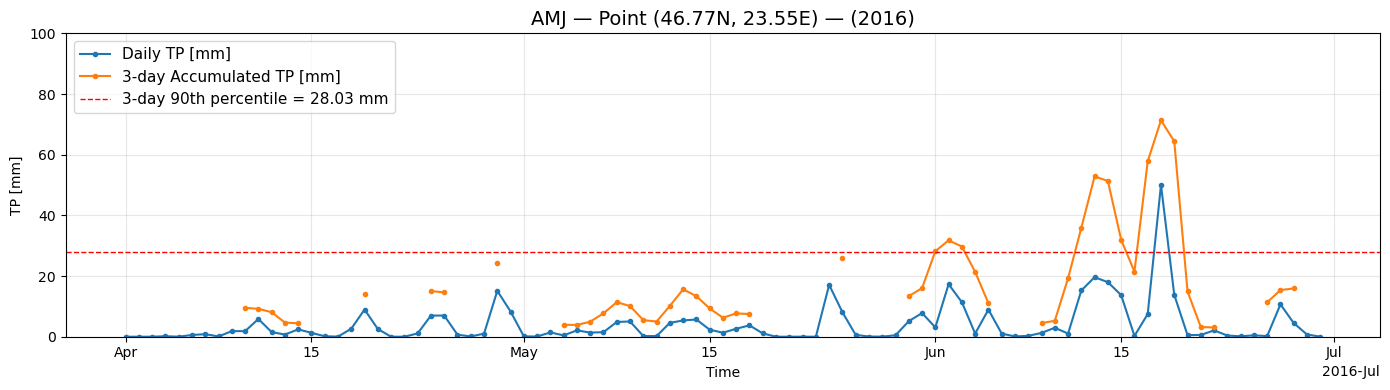

In [14]:
# plot
year = 2016

fig, ax = plt.subplots(figsize=(14,4))

# timeseries in mm
ts = (era5_TP_loc_seas.sel(time=era5_TP_loc_seas.time.dt.year == year) * 1000)
ts_acc = (era5_TP_loc_seas_acc.sel(time=era5_TP_loc_seas_acc.time.dt.year == year) * 1000)

# plot daily timeseries
ts.plot(ax=ax, color='C0', linewidth=1.5, label='Daily TP [mm]', ls='-', marker='.')
ts_acc.plot(ax=ax, color='C1', linewidth=1.5, label=f'{accumulation_time}-day Accumulated TP [mm]', ls='-', marker='.')

# quantile horizontal line (mm)
q_mm = float(q_era5_TP_loc_seas_acc.values) * 1000
q_label = f"{accumulation_time}-day {int(quantile*100)}th percentile = {q_mm:.2f} mm"
ax.axhline(q_mm, color='red', linestyle='--', linewidth=1, label=q_label)

# PQ for year (scalar)
title = f"{season} — Point ({latP:.2f}N, {lonP:.2f}E) — ({year})"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel('TP [mm]')
ax.set_xlabel('Time')
ax.set_ylim([0, 100])
ax.grid(alpha=0.3)
ax.legend(loc='upper left', fontsize=11)


plt.tight_layout()
plt.show()

# Step-4 - Extereme/intense Precipitation Events (EPE) detection

Count the number of events exceeding the threshold Q for each year. In this way, we compute an annual time series of NQp, ranging from 1940 to 2024. This is the target value we are intersted to predict.

In [15]:
# define the NQp (i.e. the number of events in season, above the Qth percentile threshold)
NQp_era5_TP_loc_seas_acc = (era5_TP_loc_seas_acc > q_era5_TP_loc_seas_acc).groupby("time.year").sum()

# assign the corresponding predictors date (useful for the feature selection)
NQp_era5_TP_loc_seas_acc['predictors_date'] = ((NQp_era5_TP_loc_seas_acc['year']).astype(str) + seasonal_dict[season]['pred_date']).astype('U10')

Visualisation of the NQp time series. Does the NQp value for the selected year agree with the number of points exceeding the threshold in the previous figure?

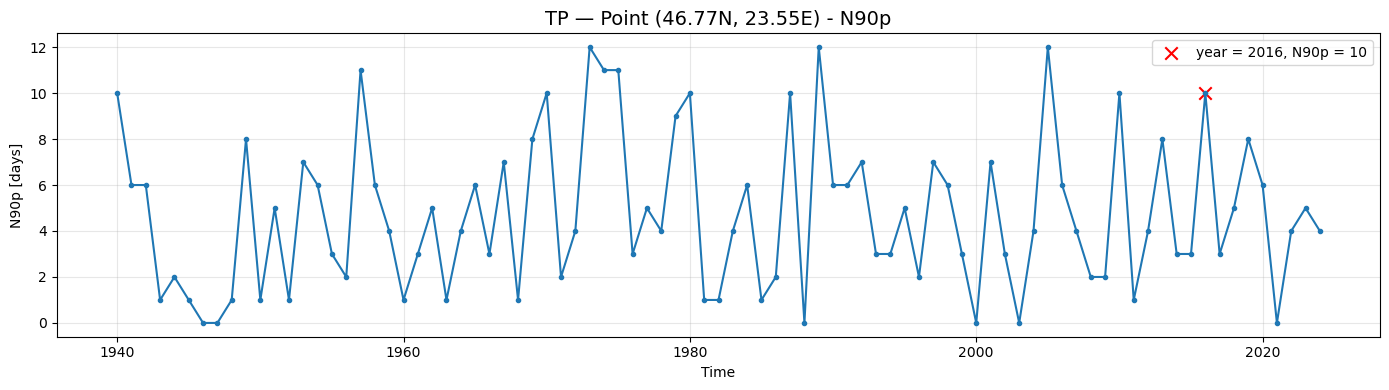

In [16]:
# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

# timeseries in years
ts = NQp_era5_TP_loc_seas_acc

# plot yearly timeseries
ts.plot(ax=ax, color='C0', linewidth=1.5, ls='-', marker='.')
ax.scatter(year, ts.sel(year=year).values, color='r', marker='x', s=80, label='year = {}, N{}p = {}'.format(year, int(quantile*100), ts.sel(year=year).values))

ax.legend()
title = f"TP — Point ({latP:.2f}N, {lonP:.2f}E) - N{int(quantile*100)}p"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel(f'N{int(quantile*100)}p [days]')
ax.set_xlabel('Time')
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

# Step-5 -Oversampling

In this setting, we are not using climate simulations. The reason is that dynamical models typically have difficulties in representing intense and extreme precipitation events. To avoid the risk of inheriting biases and errors from dynamical models, we rely on reanalysis data.

In this way, we obtain only one value per year. With such a limited dataset, even simple models can suffer from **overfitting**, i.e. learning patterns that are too closely tailored to a specific dataset and that do not generalise well to unseen data.

The most effective way to mitigate this issue is to increase the amount of training data; however, this is often not possible. An alternative approach is to generate “artificial” data to enlarge the training set, an approach known as **data augmentation**. There are several possible strategies to achieve this. In this context, one option is to oversample the data from the original time series.

In particular, we can consider **overlapping shifted seasons** around the one of interest. We can expect these to be driven by similar processes and dynamics, but with different target values and associated predictor values.

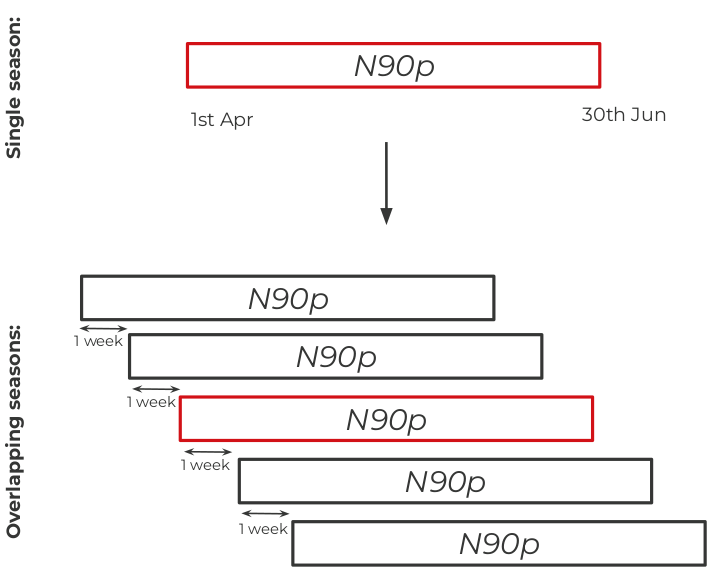

In [17]:
display(Image(filename='../overlapping.png'))

Calculate NQp for seasons shifted by 7 and 14 days, both forward and backward in time. In this way, we increase the dataset size by a factor of 5.

In [18]:
# define the number of overlapping seasons
n_over_season = 5

day_shift_list = np.linspace(n_over_season//2*-7, n_over_season//2*7, n_over_season, dtype = int)

In [19]:
# calculate the NQp for the overlapping seasons
NQp_era5_TP_loc_seas_acc_over = overlapping_season(n_over_season, era5_TP_loc, q_era5_TP_loc_seas_acc, NQp_era5_TP_loc_seas_acc,
                                                   dry_threshold, accumulation_time, months)

Visualisation of the seasonal time series for the five overlapping seasons.

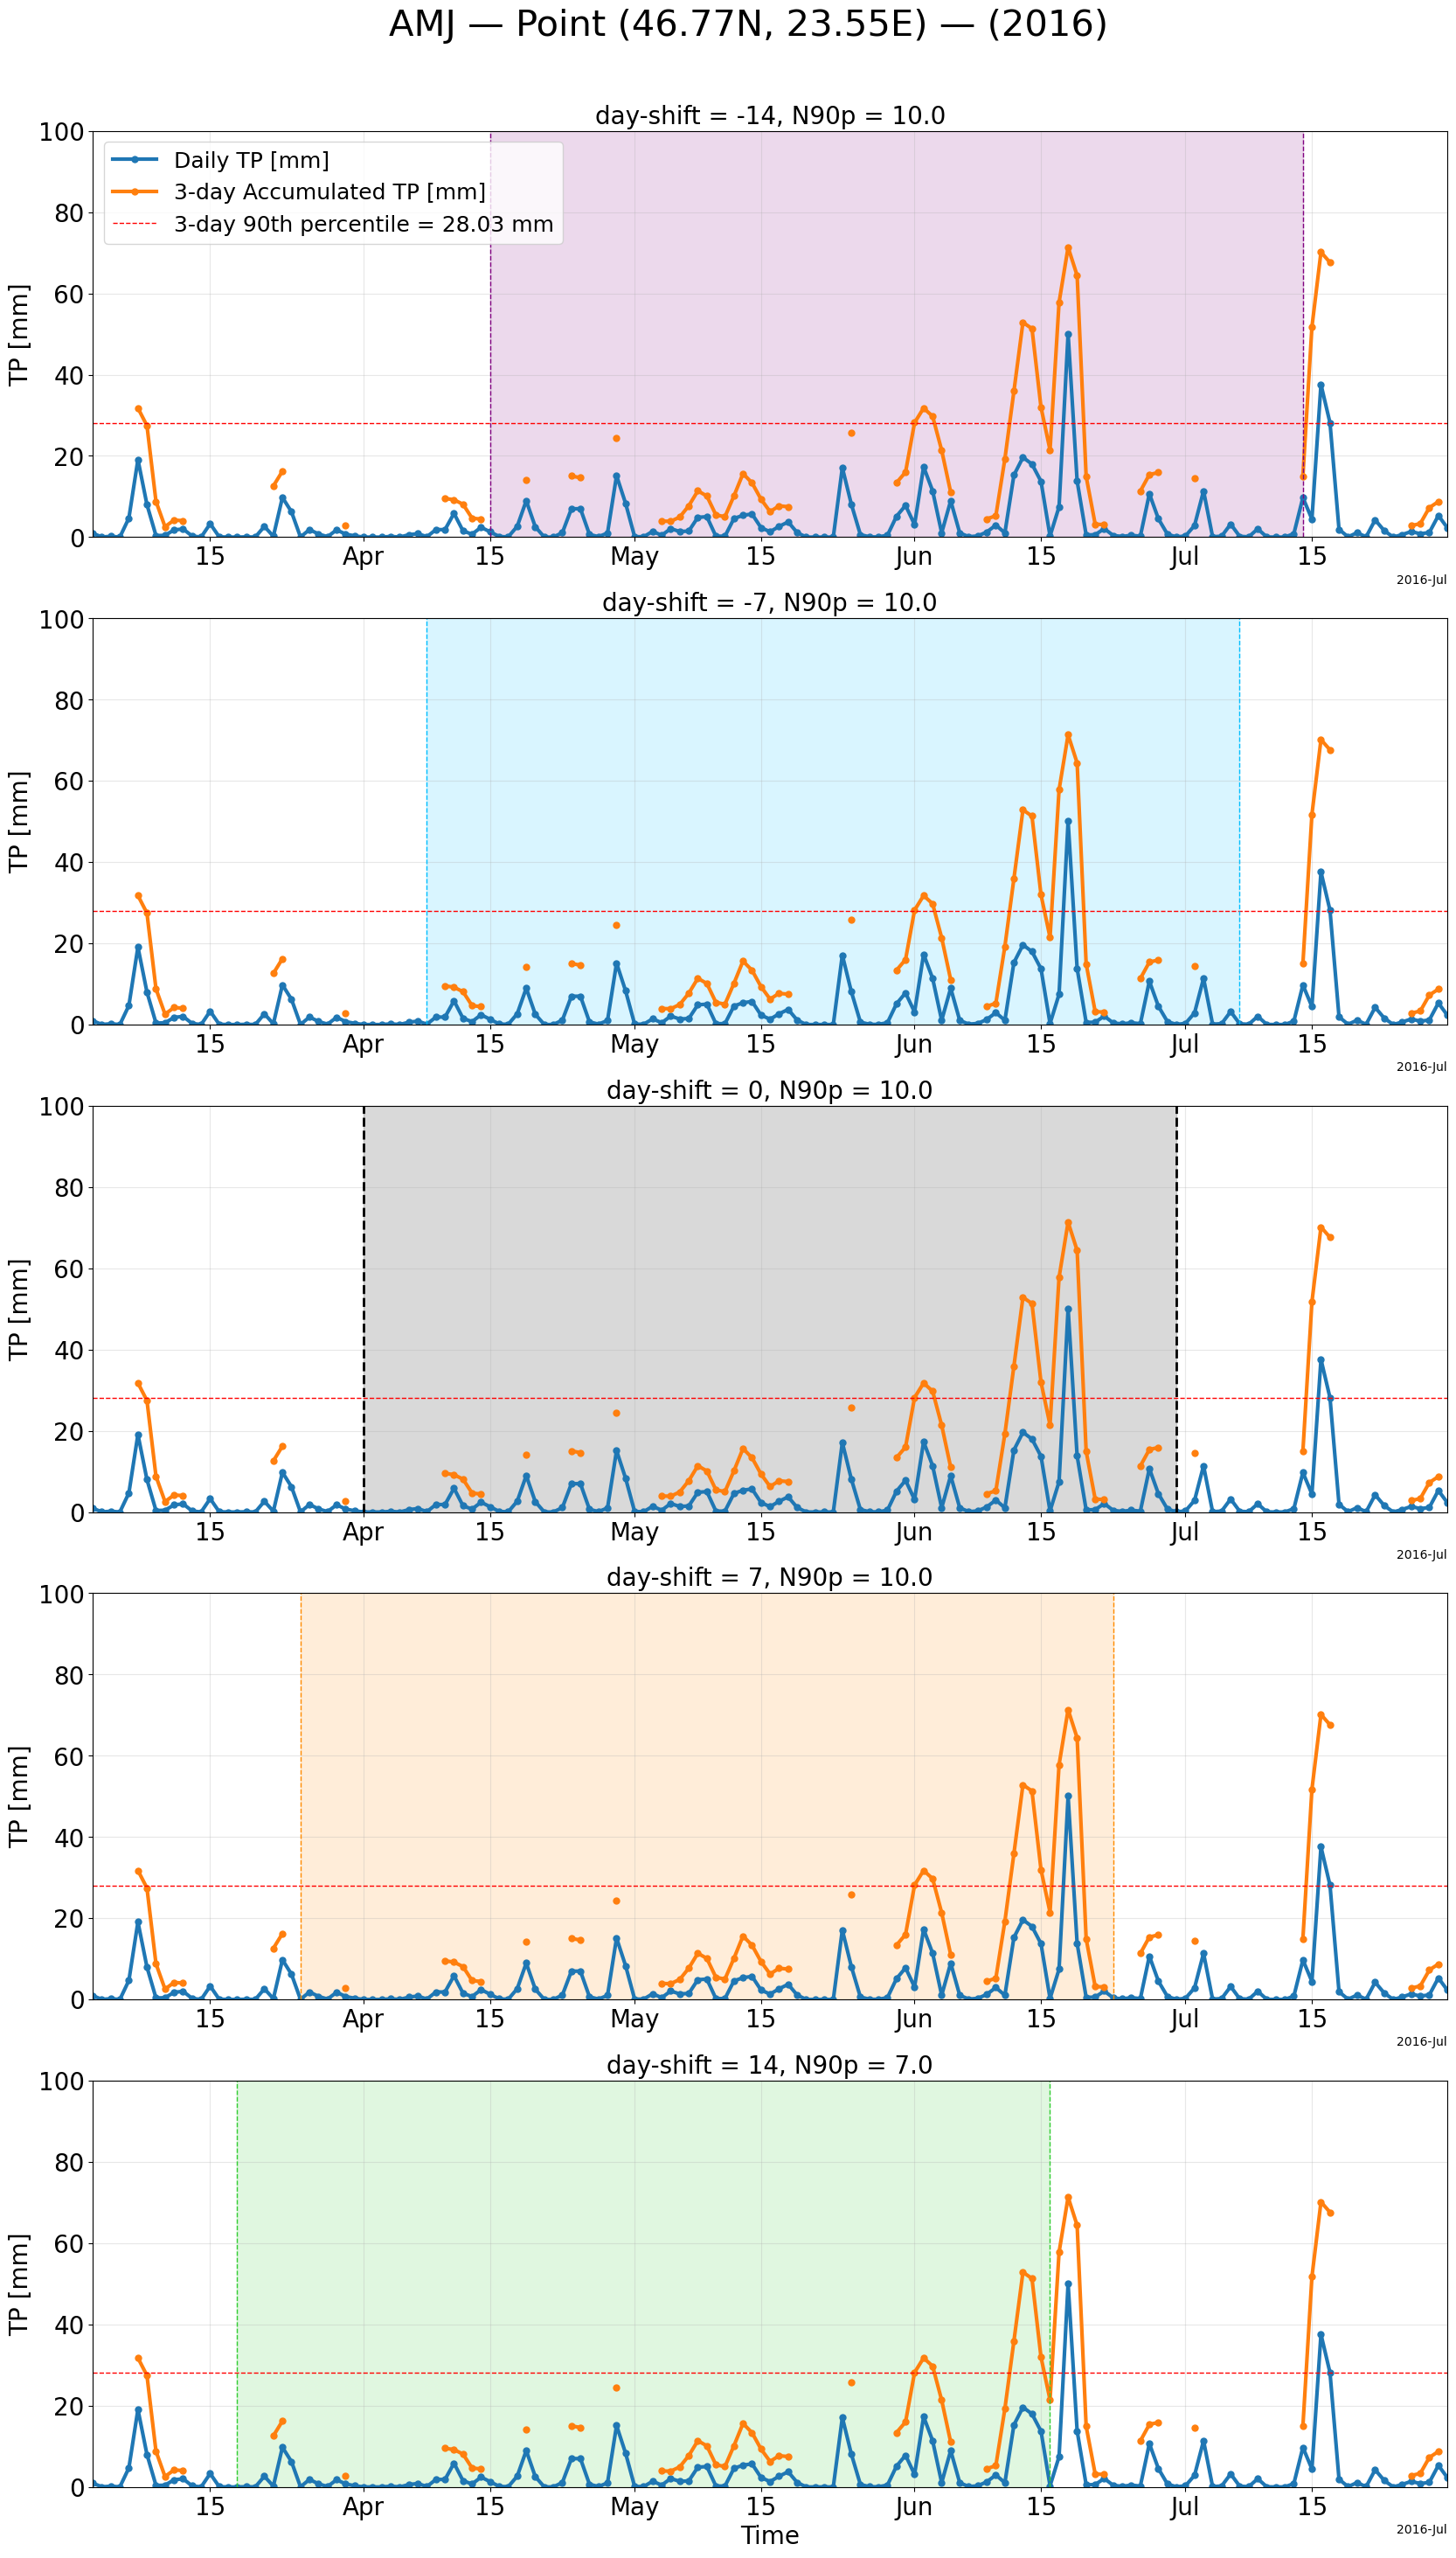

In [20]:
# plot
year = 2016

fig, ax = plt.subplots(figsize=(20,35), nrows = n_over_season)

# timeseries in mm
ts = era5_TP_loc.sel(time=((era5_TP_loc.time.dt.year == year) | (era5_TP_loc.time.dt.year == year+1))) * 1000
ts_acc = timeseries_processing(ts, dry_threshold*1000, accumulation_time, months)
# quantile horizontal line (mm)
q_mm = float(q_era5_TP_loc_seas_acc.values) * 1000
q_label = f"{accumulation_time}-day {int(quantile*100)}th percentile = {q_mm:.2f} mm"
# title
title = f"{season} — Point ({latP:.2f}N, {lonP:.2f}E) — ({year})"


# boundaries of the overlapping seasons
t0 = ts.where(ts['time'].dt.month.isin(months), drop=True).time.values[0]
t1 = ts.sel(time=((ts.time.dt.year == year))).where(ts['time'].dt.month.isin(months), drop=True).time.values[-1]

color_list = ['purple', 'deepskyblue', 'black', 'darkorange', 'limegreen', 'yellow', 'blue', 'red', 'pink']

for i in range(n_over_season):
    

    # plot daily timeseries
    ts.plot(ax=ax[i], color='C0', linewidth=3, ms=10, label='Daily TP [mm]', ls='-', marker='.')
    ts_acc.plot(ax=ax[i], color='C1', linewidth=3, ms=10, label=f'{accumulation_time}-day Accumulated TP [mm]', ls='-', marker='.')
    ax[i].axhline(q_mm, color='red', linestyle='--', linewidth=1, label=q_label)


    day_shift = day_shift_list[i]
    color = color_list[i]


    t0_str = (t0+pd.Timedelta(days=(-day_shift-1))).strftime('%Y-%m-%d')#.astype('U10')
    ax[i].axvline(t0+pd.Timedelta(days=(-day_shift)), color=color, linestyle='--', linewidth=2 if day_shift == 0 else 1)
    ax[i].axvline(t1+pd.Timedelta(days=(-day_shift)), color=color, linestyle='--', linewidth=2 if day_shift == 0 else 1)

    ax[i].axvspan(
        t0+pd.Timedelta(days=(-day_shift)),
        t1+pd.Timedelta(days=(-day_shift)),
        color=color,
        alpha=0.15
    )


    # labels, grid, legend
    ax[i].set_title(f'day-shift = {day_shift}, N{int(quantile*100)}p = {NQp_era5_TP_loc_seas_acc_over.sel(predictors_date=t0_str).tp.values}', fontsize=20)
    ax[i].set_ylabel('TP [mm]', fontsize=20)
    ax[i].tick_params(axis='both', labelsize=20)
    ax[i].set_xlabel('Time',fontsize=20)
    ax[i].set_ylim([0, 100])
    ax[i].set_xlim([t0+pd.Timedelta(days=(-30)), t1+pd.Timedelta(days=(30))])
    ax[i].grid(alpha=0.3)
    if i==0:
        #ax[i].set_title(title, fontsize=14)
        ax[i].legend(loc='upper left', fontsize=18)

    if i==n_over_season-1:
        ax[i].set_xlabel('Time',fontsize=20)

    else:
        ax[i].set_xlabel('',fontsize=20)

    #else:
        #ax[i].set_title('')

# NB note that (for graphical purpose) in this visualisation the values
# on the first and last days of central season is not displayed
# note that points on the border are not taken into consideration


plt.suptitle(title, y=0.92, fontsize=30)
#plt.tight_layout()

plt.show()

Visualisation of the NQp time series for the five overlapping seasons.

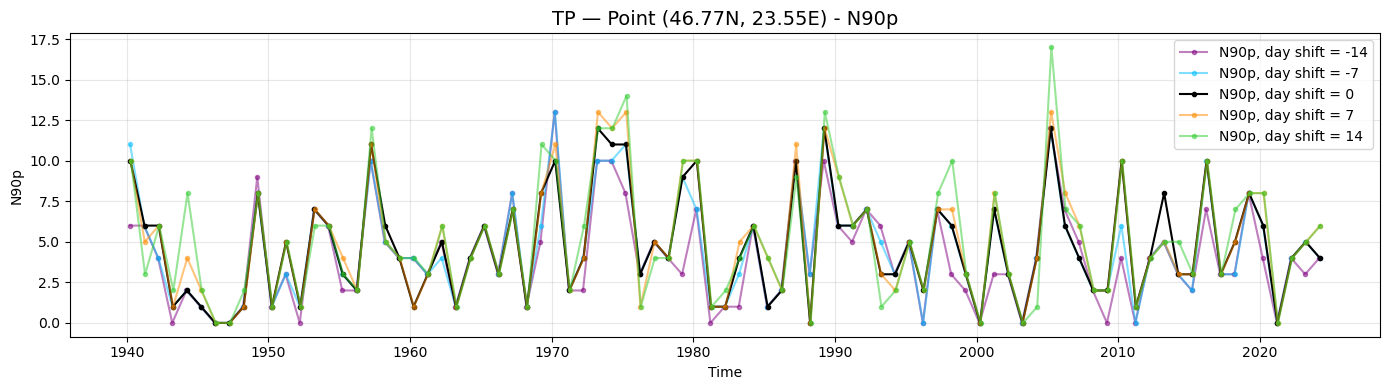

In [21]:
# plot the time series
fig, ax = plt.subplots(figsize=(14,4))

for i, day_shift in enumerate(day_shift_list):

    # timeseries in years
    ts = NQp_era5_TP_loc_seas_acc_over.tp[i::len(day_shift_list)]

    # plot yearly timeseries
    ax.plot(pd.to_datetime(ts.predictors_date),ts.values, linewidth=1.5, ls='-', marker='.',
            label='N{}p, day shift = {}'.format(int(quantile*100), day_shift), color=color_list[i],
            alpha = 1 if day_shift==0 else 0.5)
    

ax.legend()
title = f"TP — Point ({latP:.2f}N, {lonP:.2f}E) - N{int(quantile*100)}p"
ax.set_title(title, fontsize=14)

# labels, grid, legend
ax.set_ylabel(f'N{int(quantile*100)}p')
ax.set_xlabel('Time')
ax.grid(alpha=0.3)


plt.tight_layout()
plt.show()

# Step-6 - Save data

Save the data required for subsequent notebooks.

In [22]:
# Create a pandas dataframe
N90p_loc_seas_df = pd.DataFrame({'Target': NQp_era5_TP_loc_seas_acc_over.tp.values},
                                index=pd.to_datetime(NQp_era5_TP_loc_seas_acc_over['predictors_date'].values))
N90p_loc_seas_df.index.name = 'pred_date'


# convert index to object
N90p_loc_seas_df.index = N90p_loc_seas_df.index.strftime("%Y-%m-%d")

target_dataset = N90p_loc_seas_df

In [23]:
# Create filename
filename = f"Output/N{int(quantile*100)}p_{region}_ac{accumulation_time}.csv"

# Remove existing file if it exists
if os.path.exists(filename):
    os.remove(filename)

In [24]:
# Save to CSV
target_dataset.to_csv(filename, index=True)

print(f"Saved extreme precipitation events data to {filename}")

Saved extreme precipitation events data to Output/N90p_Cluj-Napoca_ac3.csv
